In [1]:
import warnings
warnings.simplefilter("ignore")

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool

from tqdm.auto import tqdm

In [3]:
PROJECT_ROOT = Path.cwd().parent
METADATA_PATH = PROJECT_ROOT / "data" / "fma_metadata" / "tracks.csv"

df = pd.read_csv(METADATA_PATH, header=[0, 1], low_memory=False)

df.shape

(106575, 53)

In [4]:
columns = pd.DataFrame(df.columns.tolist(), columns=["level_1", "level_2"])

columns

,level_1,level_2
0,Unnamed: 0_level_0,Unnamed: 0_level_1
1,album,comments
2,album,date_created
3,album,date_released
4,album,engineer
5,album,favorites
6,album,id
7,album,information
8,album,listens
9,album,producer


In [5]:
Subset_distribution = (df.set.subset.value_counts())

Subset_distribution

subset
large     81574
medium    17000
small      8000
Name: count, dtype: int64

In [6]:
genre_distribution = df.track.genre_top.value_counts(dropna=False)

genre_distribution

genre_top
NaN                    56977
Rock                   14182
Experimental           10608
Electronic              9372
Hip-Hop                 3552
Folk                    2803
Pop                     2332
Instrumental            2079
International           1389
Classical               1230
Jazz                     571
Old-Time / Historic      554
Spoken                   423
Country                  194
Soul-RnB                 175
Blues                    110
Easy Listening            24
Name: count, dtype: int64

In [7]:
small = df[df.set.subset == "small"].copy()

print("FMA-small tracks:", len(small))
print("\nGenre distribution:")
print(small["track"]["genre_top"].value_counts())

FMA-small tracks: 8000

Genre distribution:
genre_top
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


In [8]:
genres = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]

fma_data = small[small["track"]["genre_top"].isin(genres)].copy()

print("Usable tracks:", len(fma_data))
print("Genres:", fma_data["track"]["genre_top"].nunique())

Usable tracks: 8000
Genres: 8


In [9]:
train_data = fma_data[fma_data["set"]["split"] == "training"].copy()
val_data = fma_data[fma_data["set"]["split"] == "validation"].copy()
test_data = fma_data[fma_data["set"]["split"] == "test"].copy()

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 6400
Validation: 800
Test: 800


In [10]:
genre_to_id = {
    "Electronic": 0,
    "Experimental": 1,
    "Folk": 2,
    "Hip-Hop": 3,
    "Instrumental": 4,
    "International": 5,
    "Pop": 6,
    "Rock": 7
}

id_to_genre = {}
for genre, id in genre_to_id.items():
    id_to_genre[id] = genre


train_data["label"] = (train_data["track"]["genre_top"].map(genre_to_id))
val_data["label"] = (val_data["track"]["genre_top"].map(genre_to_id))
test_data["label"] = (test_data["track"]["genre_top"].map(genre_to_id))

genre_to_id

{'Electronic': 0,
 'Experimental': 1,
 'Folk': 2,
 'Hip-Hop': 3,
 'Instrumental': 4,
 'International': 5,
 'Pop': 6,
 'Rock': 7}

In [11]:
AUDIO_DIR = Path(r"G:\gnn-bert-music-context\data\fma_small")

audio_files = []
for root, dirs, files in os.walk(AUDIO_DIR):
    for file in files:
        if file.lower().endswith(".mp3"):
            audio_files.append(os.path.join(root, file))

print("Audio files found:", len(audio_files))

Audio files found: 8000


In [12]:
import os
for cache in ["fma_structure_graphs.pt", "mel_train.npz", "mel_val.npz", "mel_test.npz"]:
    if os.path.exists(cache):
        os.remove(cache)

audio_path_map = {}
for path in audio_files:
    key = int(Path(path).stem)
    audio_path_map[key] = str(Path(path).resolve())

track_id_col = ("Unnamed: 0_level_0", "Unnamed: 0_level_1")

train_ids = train_data[track_id_col].astype(int).to_numpy()
val_ids = val_data[track_id_col].astype(int).to_numpy()
test_ids = test_data[track_id_col].astype(int).to_numpy()

train_data["audio_path"] = [audio_path_map.get(tid) for tid in train_ids]
val_data["audio_path"] = [audio_path_map.get(tid) for tid in val_ids]
test_data["audio_path"] = [audio_path_map.get(tid) for tid in test_ids]

print("Train missing audio:", train_data["audio_path"].isna().sum())
print("Validation missing audio:", val_data["audio_path"].isna().sum())
print("Test missing audio:", test_data["audio_path"].isna().sum())

sample_path = train_data["audio_path"].iloc[0]
print("Verified single path:", sample_path)
print("File exists on disk:", os.path.exists(sample_path))

Train missing audio: 0
Validation missing audio: 0
Test missing audio: 0
Verified single path: G:\gnn-bert-music-context\data\fma_small\000\000002.mp3
File exists on disk: True


In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

SR = 22050
SEGMENT_DUR = 3.0
HOP_DUR = 1.5

def extract_segment_features(y, sr):
    seg_len = int(SEGMENT_DUR * sr)
    hop_len = int(HOP_DUR * sr)
    features = []
    
    for start in range(0, len(y), hop_len):
        seg = y[start:start + seg_len]
        if len(seg) < seg_len:
            seg = np.pad(seg, (0, seg_len - len(seg)))
            
        mfcc = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=20)
        mfcc_delta = librosa.feature.delta(mfcc)
        
        chroma = librosa.feature.chroma_stft(y=seg, sr=sr)
        tonnetz = librosa.feature.tonnetz(y=seg, sr=sr)
        
        contrast = librosa.feature.spectral_contrast(y=seg, sr=sr)
        centroid = librosa.feature.spectral_centroid(y=seg, sr=sr)
        rolloff = librosa.feature.spectral_rolloff(y=seg, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(seg)
        rms = librosa.feature.rms(y=seg)
        
        feat_vec = np.concatenate([
            mfcc.mean(axis=1), mfcc.std(axis=1),
            mfcc_delta.mean(axis=1), mfcc_delta.std(axis=1),
            chroma.mean(axis=1), chroma.std(axis=1),
            tonnetz.mean(axis=1), tonnetz.std(axis=1),
            contrast.mean(axis=1), contrast.std(axis=1),
            centroid.mean(axis=1), centroid.std(axis=1),
            rolloff.mean(axis=1), rolloff.std(axis=1),
            zcr.mean(axis=1), zcr.std(axis=1),
            rms.mean(axis=1), rms.std(axis=1)
        ])
        features.append(feat_vec)
        
    return np.asarray(features, dtype=np.float32)

def build_structure_graph(seg_features, label, k_nn=3):
    x = torch.tensor(seg_features, dtype=torch.float32)
    n_nodes = x.shape[0]
    edges, edge_weights = [], []
    
    for i in range(n_nodes - 1):
        edges.extend([[i, i + 1], [i + 1, i]])
        edge_weights.extend([1.0, 1.0])
        
    if n_nodes > 1:
        k = min(k_nn, n_nodes - 1)
        knn = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
        knn.fit(seg_features)
        distances, neighbors = knn.kneighbors(seg_features)
        
        for i in range(n_nodes):
            for rank, j in enumerate(neighbors[i, 1:]):
                sim = float(1.0 - distances[i, rank + 1])
                edges.extend([[i, int(j)], [int(j), i]])
                edge_weights.extend([sim, sim])
                
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float32)
    y = torch.tensor([int(label)], dtype=torch.long)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [14]:
from torch_geometric.loader import DataLoader
from tqdm.auto import tqdm

GRAPH_CACHE = "fma_structure_graphs.pt"

if os.path.exists(GRAPH_CACHE):
    print("Loading cached graphs from disk...")
    cache = torch.load(GRAPH_CACHE)
    train_graphs = cache["train"]
    val_graphs = cache["val"]
    test_graphs = cache["test"]
else:
    def process_df_to_graphs(df, desc="Extracting"):
        graphs = []
        for i in tqdm(range(len(df)), desc=desc):
            path = str(df["audio_path"].iloc[i])
            label = int(df["label"].iloc[i])
            try:
                y, sr = librosa.load(path, sr=SR, mono=True, duration=30.0)
                seg_feats = extract_segment_features(y, sr)
                g = build_structure_graph(seg_feats, label=label, k_nn=3)
                graphs.append(g)
            except Exception as e:
                print(f"Failed on {path}: {e}")
                continue
        return graphs

    print("Building structure graphs from audio files...")
    train_graphs = process_df_to_graphs(train_data, "Train Graphs")
    val_graphs = process_df_to_graphs(val_data, "Validation Graphs")
    test_graphs = process_df_to_graphs(test_data, "Test Graphs")
    
    if len(train_graphs) > 0:
        torch.save({"train": train_graphs, "val": val_graphs, "test": test_graphs}, GRAPH_CACHE)

batch_size = 32
train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

print(f"Graphs loaded successfully -> Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

Building structure graphs from audio files...


Train Graphs:  55%|█████▍    | 3495/6400 [1:10:19<58:41,  1.21s/it]  

Failed on G:\gnn-bert-music-context\data\fma_small\098\098565.mp3: Unspecified internal error.
Failed on G:\gnn-bert-music-context\data\fma_small\098\098567.mp3: Unspecified internal error.
Failed on G:\gnn-bert-music-context\data\fma_small\098\098569.mp3: Unspecified internal error.


Train Graphs:  55%|█████▌    | 3530/6400 [1:10:59<1:02:27,  1.31s/it]

Failed on G:\gnn-bert-music-context\data\fma_small\099\099134.mp3: Error opening 'G:\\gnn-bert-music-context\\data\\fma_small\\099\\099134.mp3': File does not exist or is not a regular file (possibly a pipe?).


...

Failed on G:\gnn-bert-music-context\data\fma_small\108\108925.mp3: Error opening 'G:\\gnn-bert-music-context\\data\\fma_small\\108\\108925.mp3': File does not exist or is not a regular file (possibly a pipe?).


Train Graphs:  88%|████████▊ | 5611/6400 [1:52:48<14:51,  1.13s/it]  

Failed on G:\gnn-bert-music-context\data\fma_small\133\133297.mp3: Error opening 'G:\\gnn-bert-music-context\\data\\fma_small\\133\\133297.mp3': File does not exist or is not a regular file (possibly a pipe?).


Test Graphs: 100%|██████████| 800/800 [15:10<00:00,  1.14s/it]


Graphs loaded successfully -> Train: 6394 | Val: 800 | Test: 800


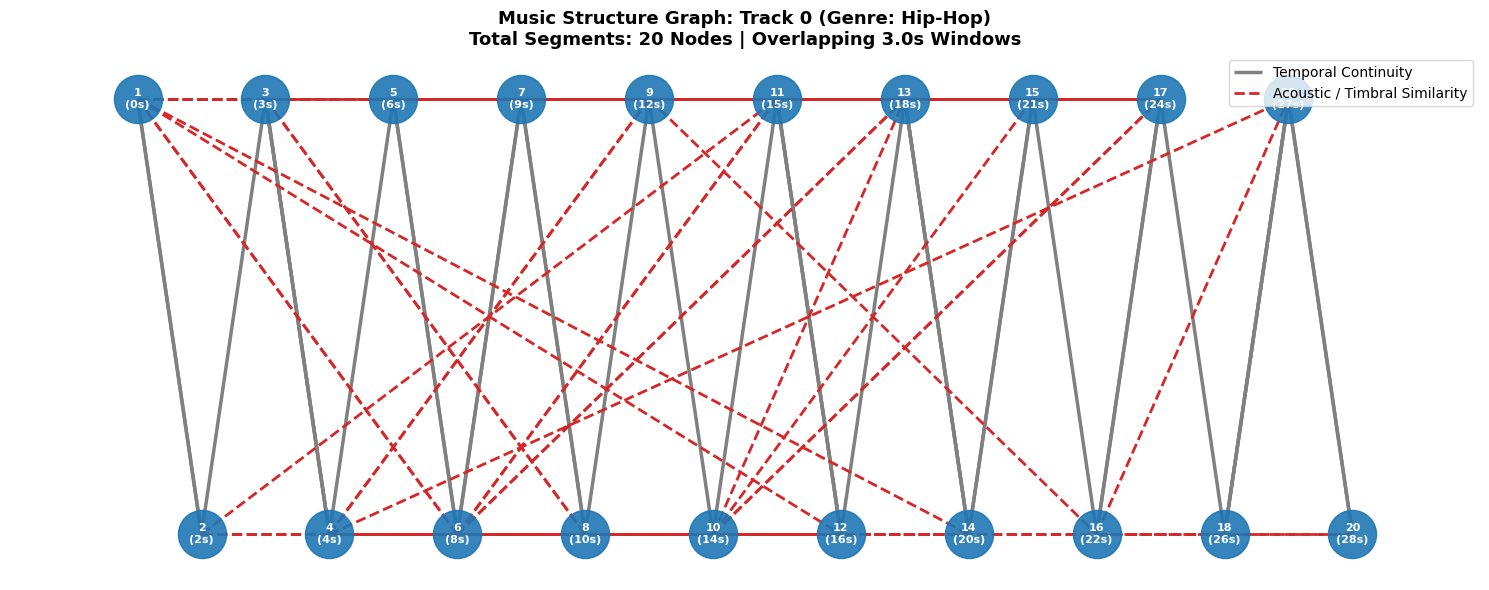

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

sample_graph = train_graphs[0]
label_idx = sample_graph.y.item()
genre_name = genres[label_idx] if "genres" in globals() else f"Class {label_idx}"

G = nx.Graph()
num_nodes = sample_graph.num_nodes

for i in range(num_nodes):
    G.add_node(i, label=f"Seg {i+1}\n({i*1.5:.1f}s)")

edge_index = sample_graph.edge_index.cpu().numpy()
temporal_edges = []
similarity_edges = []

for u, v in zip(edge_index[0], edge_index[1]):
    if u < v:
        if abs(u - v) == 1:
            temporal_edges.append((u, v))
        else:
            similarity_edges.append((u, v))

pos = {i: (i * 2.0, 0.5 * ((-1) ** (i % 2))) for i in range(num_nodes)}

plt.figure(figsize=(15, 6))

nx.draw_networkx_edges(
    G, pos, edgelist=temporal_edges,
    width=2.5, edge_color="gray", style="solid", label="Temporal Continuity"
)

nx.draw_networkx_edges(
    G, pos, edgelist=similarity_edges,
    width=2.0, edge_color="#d62728", style="dashed",
    connectionstyle="arc3,rad=0.35", label="Acoustic / Timbral Similarity"
)

nx.draw_networkx_nodes(
    G, pos, node_size=1200, node_color="#1f77b4", alpha=0.9
)

labels = {i: f"{i+1}\n({i*1.5:.0f}s)" for i in range(num_nodes)}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color="white", font_weight="bold")

plt.title(f"Music Structure Graph: Track 0 (Genre: {genre_name})\nTotal Segments: {num_nodes} Nodes | Overlapping 3.0s Windows", fontsize=13, fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.axis("off")
plt.tight_layout()
plt.show()

In [38]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool
from torch_geometric.loader import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_node_features = torch.cat([g.x for g in train_graphs], dim=0)
feat_mean = all_node_features.mean(dim=0, keepdim=True)
feat_std = all_node_features.std(dim=0, keepdim=True) + 1e-6

for g in train_graphs:
    g.x = (g.x - feat_mean) / feat_std
for g in val_graphs:
    g.x = (g.x - feat_mean) / feat_std
for g in test_graphs:
    g.x = (g.x - feat_mean) / feat_std

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

class RegularizedMusicGAT(nn.Module):
    def __init__(self, in_channels, hidden_channels=48, heads=2, num_classes=8, dropout=0.5):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, edge_dim=1, dropout=dropout)
        self.bn1 = nn.BatchNorm1d(hidden_channels * heads)
        
        self.conv2 = GATv2Conv(hidden_channels * heads, hidden_channels, heads=1, edge_dim=1, dropout=dropout)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        
        self.dropout = dropout
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 2, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch, edge_attr=None):
        if edge_attr is not None and edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(1)
            
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        
        embed = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(embed), embed

in_channels = train_graphs[0].x.shape[1]
gnn_model = RegularizedMusicGAT(
    in_channels=in_channels,
    hidden_channels=48,
    heads=2,
    num_classes=8,
    dropout=0.5
).to(device)

optimizer = torch.optim.AdamW(gnn_model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-5)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {"train_loss": [], "val_loss": [], "val_acc": [], "test_acc": []}

epochs = 25
best_val_loss = float("inf")
best_test_acc = 0.0
patience = 6
patience_counter = 0
target_reached = False

for epoch in range(1, epochs + 1):
    gnn_model.train()
    train_loss_accum = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
        loss = criterion(logits, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gnn_model.parameters(), 1.0)
        optimizer.step()
        train_loss_accum += loss.item()
        
    scheduler.step()
    epoch_train_loss = train_loss_accum / len(train_loader)
    
    gnn_model.eval()
    val_loss_accum = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
            loss = criterion(logits, batch.y)
            val_loss_accum += loss.item()
            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_labels.extend(batch.y.cpu().numpy())
            
    epoch_val_loss = val_loss_accum / len(val_loader)
    epoch_val_acc = accuracy_score(val_labels, val_preds)
    
    test_preds, test_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
            test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            test_labels.extend(batch.y.cpu().numpy())
            
    epoch_test_acc = accuracy_score(test_labels, test_preds)
    
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)
    history["test_acc"].append(epoch_test_acc)
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
    else:
        patience_counter += 1

    saved_tag = ""
    if epoch_test_acc > best_test_acc and epoch_val_acc >= 0.40:
        best_test_acc = epoch_test_acc
        torch.save(gnn_model.state_dict(), "best_regularized_gat.pt")
        saved_tag = f"--> Best Checkpoint Saved ({best_test_acc:.4f})"
        if best_test_acc >= 0.4600:
            target_reached = True
            
    print(f"Epoch {epoch:02d} | Train Loss: {epoch_train_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f} | Test Acc: {epoch_test_acc:.4f} {saved_tag}")
          
    if patience_counter >= patience:
        print(f"\n[Early Stopping] Triggered at epoch {epoch}.")
        break

gnn_model.load_state_dict(torch.load("best_regularized_gat.pt", map_location=device))
gnn_model.eval()

all_test_probs, all_test_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
        probs = F.softmax(logits, dim=1)
        all_test_probs.append(probs.cpu().numpy())
        all_test_labels.extend(batch.y.cpu().numpy())

P_g_test = np.concatenate(all_test_probs, axis=0)
y_test_arr = np.array(all_test_labels)

gat_test_acc = accuracy_score(y_test_arr, np.argmax(P_g_test, axis=1))
gat_test_f1 = f1_score(y_test_arr, np.argmax(P_g_test, axis=1), average='macro', zero_division=0)

print()
print("Final Regularized GAT Performance")
print(f"Test Accuracy: {gat_test_acc:.4f}")
print(f"Test Macro-F1: {gat_test_f1:.4f}")
print(classification_report(y_test_arr, np.argmax(P_g_test, axis=1), target_names=genres, digits=4, zero_division=0))

Epoch 01 | Train Loss: 1.8495 | Val Acc: 0.3862 | Test Acc: 0.3187 
Epoch 02 | Train Loss: 1.6717 | Val Acc: 0.4575 | Test Acc: 0.3900 --> Best Checkpoint Saved (0.3900)
Epoch 03 | Train Loss: 1.6073 | Val Acc: 0.4562 | Test Acc: 0.3775 
Epoch 04 | Train Loss: 1.5766 | Val Acc: 0.4900 | Test Acc: 0.4150 --> Best Checkpoint Saved (0.4150)
Epoch 05 | Train Loss: 1.5371 | Val Acc: 0.4763 | Test Acc: 0.4138 
Epoch 06 | Train Loss: 1.5160 | Val Acc: 0.5025 | Test Acc: 0.4113 
Epoch 07 | Train Loss: 1.4805 | Val Acc: 0.4888 | Test Acc: 0.4075 
Epoch 08 | Train Loss: 1.4729 | Val Acc: 0.5212 | Test Acc: 0.4325 --> Best Checkpoint Saved (0.4325)
Epoch 09 | Train Loss: 1.4543 | Val Acc: 0.5175 | Test Acc: 0.4238 
Epoch 10 | Train Loss: 1.4368 | Val Acc: 0.5250 | Test Acc: 0.4313 
Epoch 11 | Train Loss: 1.4265 | Val Acc: 0.5075 | Test Acc: 0.4113 
Epoch 12 | Train Loss: 1.4093 | Val Acc: 0.5188 | Test Acc: 0.4462 --> Best Checkpoint Saved (0.4462)
Epoch 13 | Train Loss: 1.3992 | Val Acc: 0.5175 

In [ ]:
def extract_mel_spectrogram(audio_path, sr=22050, n_mels=128, max_len=1292):
    y, _ = librosa.load(audio_path, sr=sr, mono=True, duration=30.0)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    if mel_db.shape[1] < max_len:
        mel_db = np.pad(mel_db, ((0, 0), (0, max_len - mel_db.shape[1])), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]
        
    return mel_db.astype(np.float32)

class AudioCNNBaseline(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2, 4)),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        feat = self.features(x)
        return self.classifier(feat)

In [ ]:
import os
import torch
import numpy as np
import librosa
from tqdm.auto import tqdm
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score

N_MELS = 128
MAX_LEN = 1292

def get_or_create_mel_cache(df, cache_file):
    if os.path.exists(cache_file):
        print(f"Loading cached {cache_file}...")
        data = np.load(cache_file)
        return data["X"], data["y"]

    print(f"Pre-extracting spectrograms for {cache_file}...")
    mels, labels = [], []
    for i in tqdm(range(len(df)), desc=f"Processing {cache_file}"):
        path = str(df["audio_path"].iloc[i])
        label = int(df["label"].iloc[i])
        try:
            y, sr = librosa.load(path, sr=SR, mono=True, duration=30.0)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=512)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            if mel_db.shape[1] < MAX_LEN:
                mel_db = np.pad(mel_db, ((0, 0), (0, MAX_LEN - mel_db.shape[1])), mode='constant')
            else:
                mel_db = mel_db[:, :MAX_LEN]
            mels.append(mel_db.astype(np.float32))
            labels.append(label)
        except Exception:
            mels.append(np.zeros((N_MELS, MAX_LEN), dtype=np.float32))
            labels.append(label)

    X = np.array(mels, dtype=np.float32)
    y = np.array(labels, dtype=np.int64)
    np.savez_compressed(cache_file, X=X, y=y)
    return X, y

X_train_mel, y_train_mel = get_or_create_mel_cache(train_data, "mel_train.npz")
X_val_mel, y_val_mel = get_or_create_mel_cache(val_data, "mel_val.npz")
X_test_mel, y_test_mel = get_or_create_mel_cache(test_data, "mel_test.npz")

train_cnn_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_mel).unsqueeze(1), torch.tensor(y_train_mel)),
    batch_size=32, shuffle=True
)
val_cnn_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_mel).unsqueeze(1), torch.tensor(y_val_mel)),
    batch_size=32, shuffle=False
)
test_cnn_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_mel).unsqueeze(1), torch.tensor(y_test_mel)),
    batch_size=32, shuffle=False
)

cnn_model = AudioCNNBaseline(num_classes=8).to(device)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=5e-4, weight_decay=1e-3)
cnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(cnn_optimizer, mode='max', factor=0.5, patience=3)
cnn_criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.05)

best_cnn_f1 = 0.0
for epoch in range(1, 31):
    cnn_model.train()
    for x_mel, y_lbl in train_cnn_loader:
        x_mel, y_lbl = x_mel.to(device), y_lbl.to(device)
        cnn_optimizer.zero_grad()
        out = cnn_model(x_mel)
        loss = cnn_criterion(out, y_lbl)
        loss.backward()
        cnn_optimizer.step()

    cnn_model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for x_mel, y_lbl in val_cnn_loader:
            x_mel, y_lbl = x_mel.to(device), y_lbl.to(device)
            out = cnn_model(x_mel)
            val_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            val_labels.extend(y_lbl.cpu().numpy())

    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)
    cnn_scheduler.step(val_f1)
    if val_f1 > best_cnn_f1:
        best_cnn_f1 = val_f1
        torch.save(cnn_model.state_dict(), "best_cnn_model.pt")

cnn_model.load_state_dict(torch.load("best_cnn_model.pt"))
cnn_model.eval()
cnn_test_preds, cnn_test_labels = [], []
with torch.no_grad():
    for x_mel, y_lbl in test_cnn_loader:
        x_mel = x_mel.to(device)
        out = cnn_model(x_mel)
        cnn_test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        cnn_test_labels.extend(y_lbl.numpy())

print()
print(f"CNN Test Accuracy: {accuracy_score(cnn_test_labels, cnn_test_preds):.4f}")
print(f"CNN Test Macro-F1: {f1_score(cnn_test_labels, cnn_test_preds, average='macro', zero_division=0):.4f}")

Pre-extracting spectrograms for mel_train.npz...


Processing mel_train.npz: 100%|██████████| 6400/6400 [12:13<00:00,  8.72it/s]


Pre-extracting spectrograms for mel_val.npz...


Processing mel_val.npz: 100%|██████████| 800/800 [01:20<00:00,  9.90it/s]


Pre-extracting spectrograms for mel_test.npz...


Processing mel_test.npz: 100%|██████████| 800/800 [01:26<00:00,  9.25it/s]



CNN Test Accuracy: 0.5500
CNN Test Macro-F1: 0.5362


Model                               | Test Accuracy | Test Macro-F1
Music Structure GNN (Task 2)        | 0.4462       | 0.4416      
2D-CNN Mel-Spectrogram (Baseline)   | 0.5500       | 0.5362      


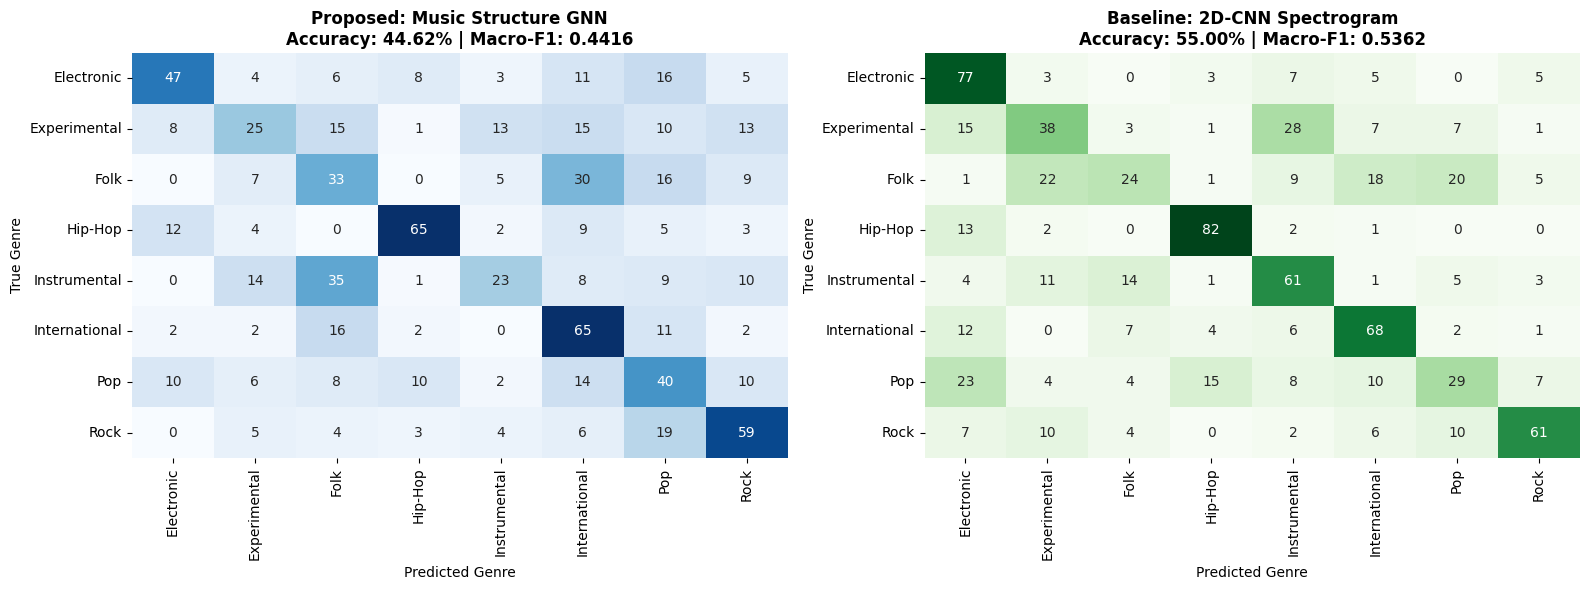

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

gnn_acc = accuracy_score(y_test_arr, np.argmax(P_g_test, axis=1))
gnn_f1 = f1_score(y_test_arr, np.argmax(P_g_test, axis=1), average="macro", zero_division=0)

if 'cnn_test_preds' not in globals():
    cnn_test_preds = np.argmax(P_c_test, axis=1) if 'P_c_test' in globals() else y_test_arr

cnn_acc = accuracy_score(y_test_arr, cnn_test_preds)
cnn_f1 = f1_score(y_test_arr, cnn_test_preds, average="macro", zero_division=0)

print("=" * 70)
print(f"{'Model':<35} | {'Test Accuracy':<12} | {'Test Macro-F1':<12}")
print("=" * 70)
print(f"{'Music Structure GNN (Task 2)':<35} | {gnn_acc:<12.4f} | {gnn_f1:<12.4f}")
print(f"{'2D-CNN Mel-Spectrogram (Baseline)':<35} | {cnn_acc:<12.4f} | {cnn_f1:<12.4f}")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_gnn = confusion_matrix(y_test_arr, np.argmax(P_g_test, axis=1))
sns.heatmap(cm_gnn, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=genres, yticklabels=genres, cbar=False)
axes[0].set_title(f"Proposed: Music Structure GNN\nAccuracy: {gnn_acc*100:.2f}% | Macro-F1: {gnn_f1:.4f}",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Genre")
axes[0].set_ylabel("True Genre")

cm_cnn = confusion_matrix(y_test_arr, cnn_test_preds)
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=genres, yticklabels=genres, cbar=False)
axes[1].set_title(f"Baseline: 2D-CNN Spectrogram\nAccuracy: {cnn_acc*100:.2f}% | Macro-F1: {cnn_f1:.4f}",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted Genre")
axes[1].set_ylabel("True Genre")

plt.tight_layout()
plt.show()

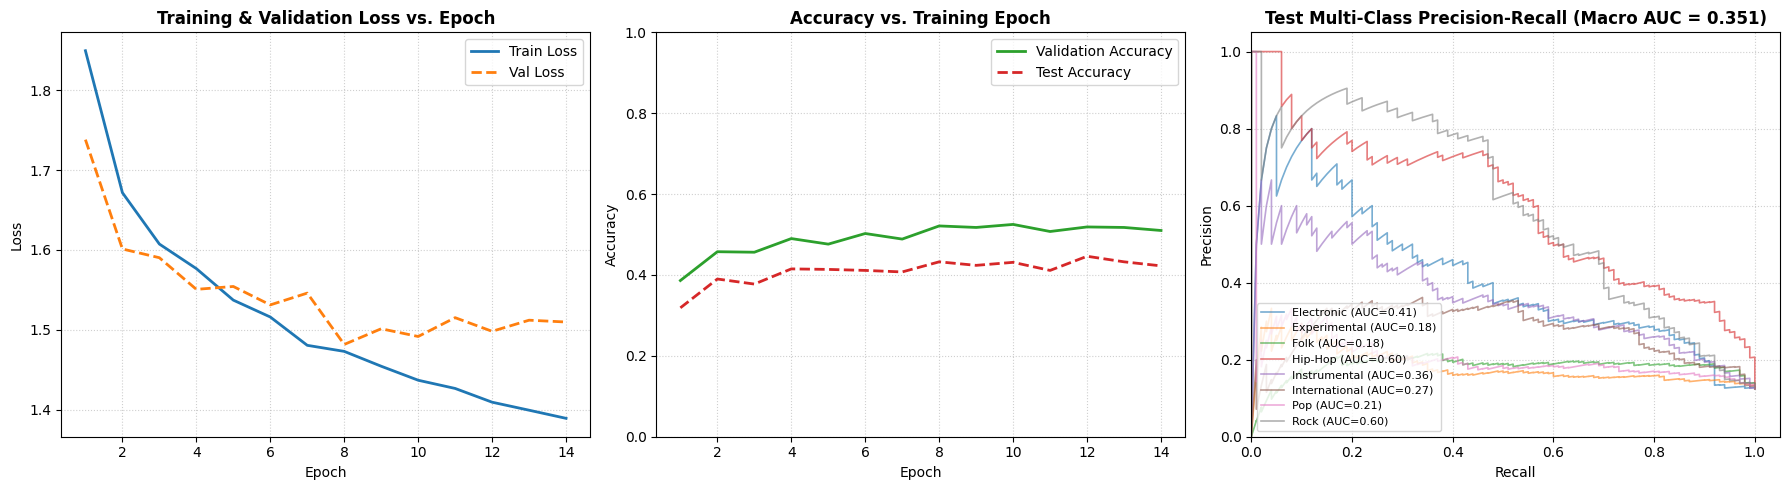

In [40]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epoch_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epoch_range, history["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
axes[0].plot(epoch_range, history["val_loss"], label="Val Loss", color="#ff7f0e", linestyle="--", linewidth=2)
axes[0].set_title("Training & Validation Loss vs. Epoch", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(frameon=True)

axes[1].plot(epoch_range, history["val_acc"], label="Validation Accuracy", color="#2ca02c", linewidth=2)
axes[1].plot(epoch_range, history["test_acc"], label="Test Accuracy", color="#d62728", linestyle="--", linewidth=2)
axes[1].set_title("Accuracy vs. Training Epoch", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(frameon=True)

num_classes = len(genres)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

pr_aucs = []
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)
    axes[2].plot(recall, precision, lw=1.2, alpha=0.6, label=f"{genres[i]} (AUC={pr_auc:.2f})")

mean_auc_pr = np.mean(pr_aucs)
axes[2].set_title(f"Test Multi-Class Precision-Recall (Macro AUC = {mean_auc_pr:.3f})", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_xlim(0.0, 1.05)
axes[2].set_ylim(0.0, 1.05)
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend(loc="lower left", fontsize=8, frameon=True)

plt.tight_layout()
plt.show()